## 2.1 Cart-pole swing-up with limited actuation

**(a)**

The convex approximation (LOCP) around the current iterate $(s^{(i)}, u^{(i)})$ is

$$
\begin{aligned}
\operatorname{minimize}_{s,\,u} \quad
  & (s_N - s_{\text{goal}})^\top P\,(s_N - s_{\text{goal}}) \\
  & + \sum_{k=0}^{N-1}\left[(s_k - s_{\text{goal}})^\top Q\,(s_k - s_{\text{goal}}) + u_k^\top R\,u_k\right] \\
\text{subject to} \quad
  & s_0 = \bar{s}_0 \\
  & u_k \in \mathcal{U}, \quad \forall k \in \{0,\ldots,N-1\} \\
  & \|u_k - u_k^{(i)}\|_\infty \leq \rho, \quad \forall k \in \{0,\ldots,N-1\} \\
  & \|s_k - s_k^{(i)}\|_\infty \leq \rho, \quad \forall k \in \{0,\ldots,N\} \\
  & s_{k+1} = A_k s_k + B_k u_k + c_k, \quad \forall k \in \{0,\ldots,N-1\}
\end{aligned}
$$

where the terminal constraint $s_N = s_{\text{goal}}$ is replaced by the terminal cost $(s_N - s_{\text{goal}})^\top P\,(s_N - s_{\text{goal}})$, and $A_k$, $B_k$, $c_k$ come from the linearization as follow:

$$
s_{k+1}
= f_\mathbf{d}\!\left(s_k^{(i)}, u_k^{(i)}\right)
+ \frac{\partial f_\mathbf{d}}{\partial s}\!\left(s_k^{(i)}, u_k^{(i)}\right)\!\left(s_k - s_k^{(i)}\right)
+ \frac{\partial f_\mathbf{d}}{\partial u}\!\left(s_k^{(i)}, u_k^{(i)}\right)\!\left(u_k - u_k^{(i)}\right)
= A_k s_k + B_k u_k + c_k
$$

with

$$
A_k = \frac{\partial f_\mathbf{d}}{\partial s}\!\left(s_k^{(i)}, u_k^{(i)}\right), \qquad
B_k = \frac{\partial f_\mathbf{d}}{\partial u}\!\left(s_k^{(i)}, u_k^{(i)}\right), \qquad
c_k = f_\mathbf{d}\!\left(s_k^{(i)}, u_k^{(i)}\right) - A_k s_k^{(i)} - B_k u_k^{(i)}
$$

**(b)**
Please see `cartpole_swingup_constrained.py`.

**(c)**

Please see `cartpole_swingup_constrained.py`.

**(d)**

 88%|████████▊ | 88/100 [01:12<00:09,  1.22it/s, objective change=0.32265]  


SCP converged after 88 iterations.


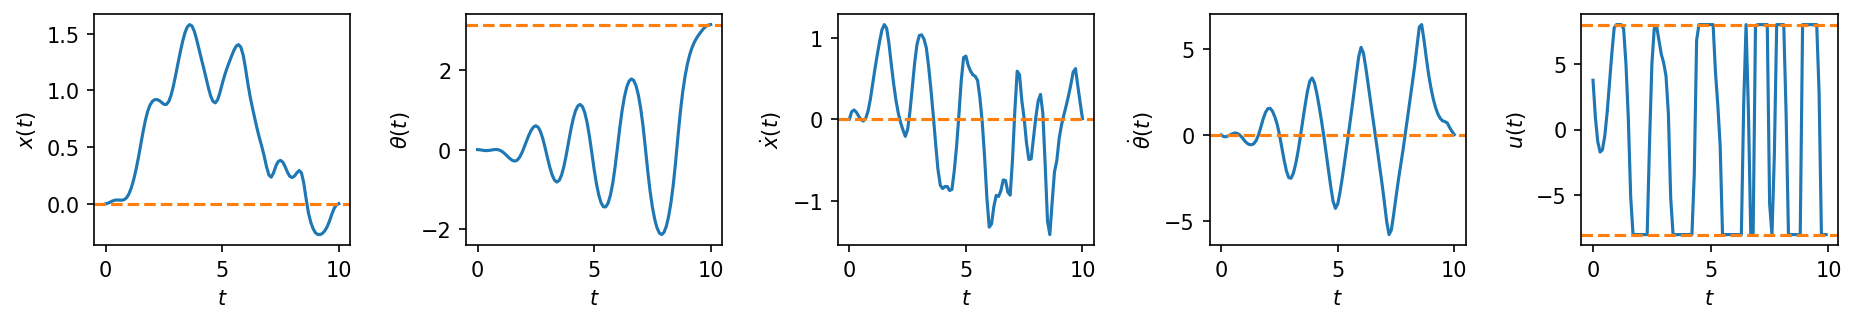

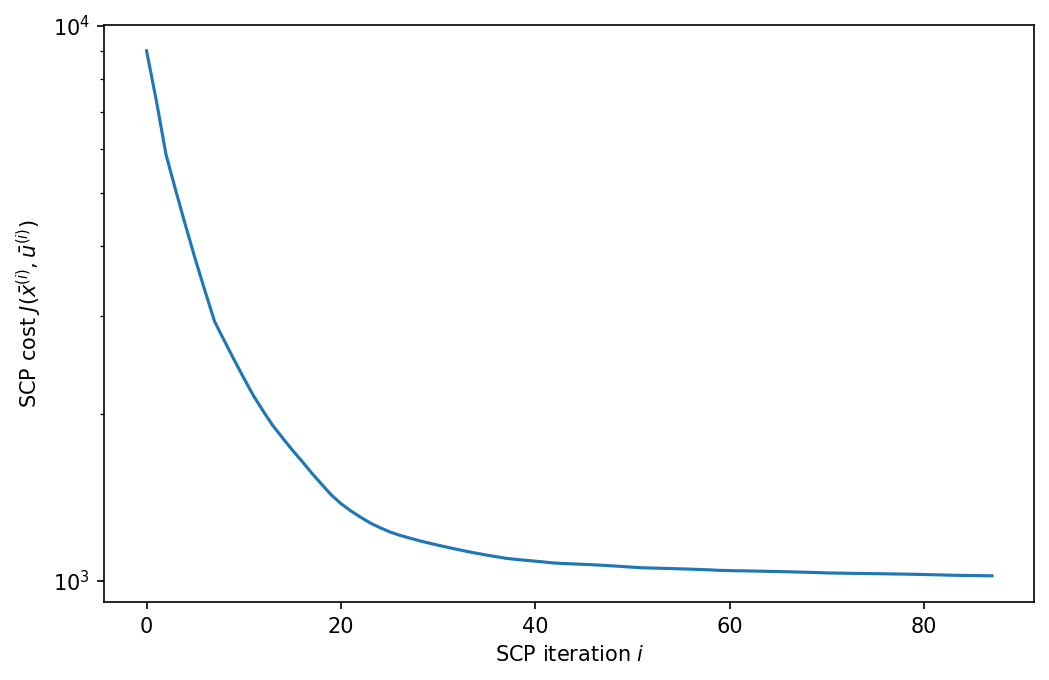

In [1]:
%run cartpole_swingup_constrained.py

The pendulum just reaches $s_\text{goal}$ at the end of the horizon but does not stay there. A natural scheme is to use SCP to generate the swing-up trajectory, then switch to a closed-loop LQR controller linearized around the upright equilibrium to keep the pendulum there indefinitely.